# A1 — Baysor / SSAM on real MERSCOPE WT vs AD: filtering, WT/AD DE, and pathway check

Post-hoc analysis of the raw detections from the HGCC sweep
(`../run_{baysor,ssam}_tile.py` → `../concat_spheres.py` → `../output/<method>/<config>/spheres.parquet`).

**Two parallel settings**, analyzed separately throughout (`param = tuned` in both):

| geneset | input to detection | populations |
|---|---|---|
| `all` | full 290-gene panel | `pop1`, `pop2`, `pop3` |
| `markers` | the 20 mcDETECT `syn_genes` | `pop1`, `pop2` |

| population | definition |
|---|---|
| `pop1` | all detections |
| `pop2` | out-of-nucleus — `in_soma_ratio < IN_SOMA_THR` (0.1, mcDETECT's own cutoff) |
| `pop3` | `pop2` **and** `marker_frac >= MARKER_FRAC_THR` — **`all` setting only** |

Both thresholds live in `postproc_config.py`; section 3 prints a scan of `pop3` sizes across
candidate `marker_frac` cutoffs so `MARKER_FRAC_THR` can be retuned with one constant and a re-run.
It is an **absolute, uniform** cutoff on purpose — a per-sample one would give AD a looser bar (its
panel-wide marker background is 0.296 vs WT's 0.3235) and so would filter the two arms of the WT/AD
contrast asymmetrically.

`pop3` exists only for `all`: in the `markers` setting every transcript that formed the detection is
already a granule marker, so a marker-enrichment filter is vacuous. `param = default` is used *only*
as a scale check in section 1.

**In-nucleus denominator (both settings).** Primary = **all** transcripts in the sphere
(`in_soma_ratio_all`); the mcDETECT-identical **marker-only** ratio (`in_soma_ratio_marker`,
`pop2_marker`) is reported alongside as a sensitivity check. mcDETECT itself uses marker-only
(`model.py:102`, `258-267`), but under `all` many tuned Baysor spheres hold zero marker transcripts,
which would make that ratio undefined and collapse `pop2` into `pop3`.

**Expression quantification.** Every detection is quantified by the transcripts inside its
**enclosing sphere**, for both methods — mcDETECT's granule expression is sphere capture and SSAM
emits no molecule assignment, so this is the only rule that isolates the detection difference. For
Baysor the sphere captures a median ~1.4× more transcripts than Baysor assigns to that cell
(q95 ≈ 2.7×); disclose in Methods.

**DE at two levels.** Per detection (10⁶ pseudoreplicates, matches
`code/7_neuropil_subdomains.ipynb`'s call) **and** per 50 µm pseudo-spot (10³–10⁴ units, the same
spatial scale as the published `neuropil_subdomains_Isocortex_50` analysis).

**Expected result.** mcDETECT's pathways should *not* sit at the top of the WT-vs-AD ranking for
`pop1`/`pop2`; they may for `pop3` / the `markers` setting.

Run from this directory (`R2_revision/baysor_ssam_merscope/postproc/`) in `mcDETECT-env`.
Granule subtyping and the microdomain chain live in the companion notebook
`A1_granule_subtypes.ipynb` (`markers` setting only).


In [1]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

import anndata
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import scanpy as sc

sys.path.insert(0, str(Path.cwd()))          # run this notebook from postproc/
import postproc_config as C
import sphere_features as SF

warnings.filterwarnings("ignore")
sc.settings.verbosity = 1

C.POSTPROC_DIR.mkdir(parents=True, exist_ok=True)

# ---------------- runtime knobs ---------------- #
OVERWRITE = False       # True -> recompute the cached per-detection profiles / DE / GSEA
MAX_SPHERES = None      # e.g. 200_000 for a fast dry run (results are NOT cached); None = full data
DE_MAX_CELLS = None     # cap detections per condition in the detection-level DE; None = use all

CONFIGS = [(m, g) for m in C.METHODS for g in C.GENESETS]

print("detections :", C.OUT_ROOT)
print("postproc   :", C.POSTPROC_DIR)
print("param      :", C.PARAM, "| genesets:", C.GENESETS, "| methods:", C.METHODS)
print("thresholds : in_soma <", C.IN_SOMA_THR, "| marker_frac >=", C.MARKER_FRAC_THR)
print("spot grid  :", C.SPOT_GRID, "um")


/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/Users/chenyang/miniconda3/envs/mcDETECT-env/lib/python3.10/site-p

detections : /Users/chenyang/Desktop/mcDETECT/R2_revision/baysor_ssam_merscope/output
postproc   : /Users/chenyang/Desktop/mcDETECT/R2_revision/baysor_ssam_merscope/output/postproc
param      : tuned | genesets: ['all', 'markers'] | methods: ['baysor', 'ssam']
thresholds : in_soma < 0.1 | marker_frac >= 0.4
spot grid  : 50.0 um


## 1. Scale check — both methods are off by orders of magnitude at their default settings

The only use of the `default` parameter arm: a bare count of detections next to mcDETECT's granule
count, for both gene sets. No filtering, no profiling.


In [2]:
summary = pd.read_csv(C.OUT_ROOT / "spheres_summary.csv")
assert (summary["n_tiles_missing"] == 0).all(), "sweep is incomplete -- rerun concat on HGCC"

# mcDETECT's final granules (row counts straight from the parquet footer)
mc_counts = {s: pq.ParquetFile(C.mcdetect_granules_path(s)).metadata.num_rows for s in C.SAMPLES}
print("mcDETECT granules:", mc_counts)

scale = summary.copy()
scale["mcdetect_granules"] = scale["sample"].map(mc_counts)
scale["ratio_vs_mcdetect"] = scale["n_spheres"] / scale["mcdetect_granules"]
scale = scale[["method", "geneset", "param", "sample", "n_spheres",
               "mcdetect_granules", "ratio_vs_mcdetect"]].sort_values(
                   ["method", "geneset", "param", "sample"])
scale.to_csv(C.POSTPROC_DIR / "detection_counts_vs_mcdetect.csv", index=False)
scale


mcDETECT granules: {'WT': 681337, 'AD': 398809}


,method,geneset,param,sample,n_spheres,mcdetect_granules,ratio_vs_mcdetect
4,baysor,all,default,AD,7324,398809,0.018365
0,baysor,all,default,WT,8968,681337,0.013162
6,baysor,all,tuned,AD,2464532,398809,6.179730
2,baysor,all,tuned,WT,3527958,681337,5.177993
5,baysor,markers,default,AD,5886,398809,0.014759
1,baysor,markers,default,WT,8187,681337,0.012016
7,baysor,markers,tuned,AD,687274,398809,1.723316
3,baysor,markers,tuned,WT,1083376,681337,1.590074
12,ssam,all,default,AD,97653,398809,0.244862
8,ssam,all,default,WT,97906,681337,0.143697


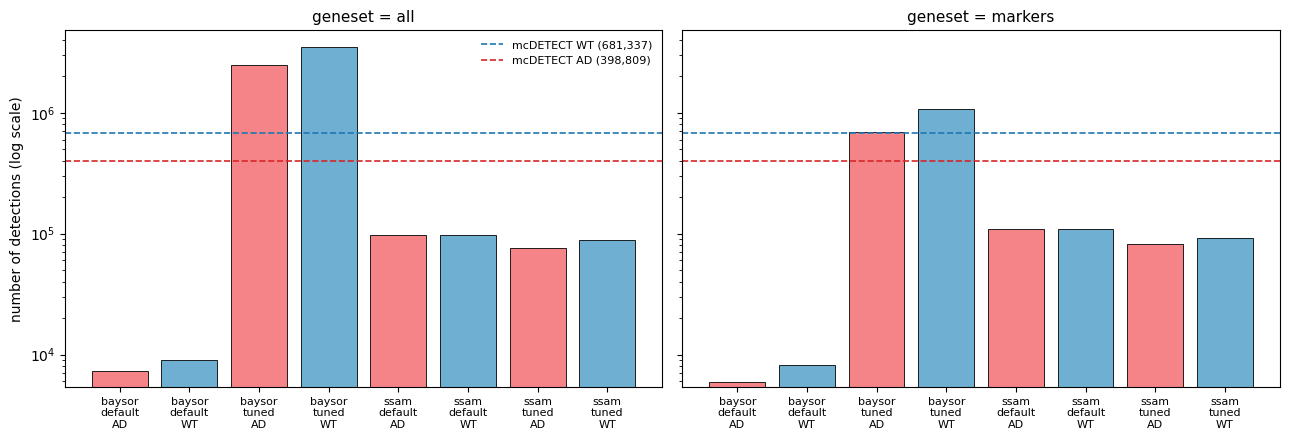

In [3]:
fig, axes = plt.subplots(1, len(C.GENESETS), figsize=(13, 4.5), sharey=True)
for ax, geneset in zip(np.atleast_1d(axes), C.GENESETS):
    sub = scale[scale["geneset"] == geneset]
    labels = [f"{r.method}\n{r.param}\n{r['sample']}" for _, r in sub.iterrows()]
    colors = ["#6fafd2" if r["sample"] == "WT" else "#f48488" for _, r in sub.iterrows()]
    ax.bar(range(len(sub)), sub["n_spheres"], color=colors, edgecolor="black", linewidth=0.6)
    for s, c in zip(C.SAMPLES, ["#1f77b4", "#d62728"]):
        ax.axhline(mc_counts[s], ls="--", lw=1.2, color=c, label=f"mcDETECT {s} ({mc_counts[s]:,})")
    ax.set_yscale("log")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(f"geneset = {geneset}", fontsize=11)

np.atleast_1d(axes)[0].set_ylabel("number of detections (log scale)")
np.atleast_1d(axes)[0].legend(fontsize=8, frameon=False)
fig.tight_layout()
fig.savefig(C.POSTPROC_DIR / "detection_counts_vs_mcdetect.jpeg", dpi=300)
plt.show()


## 2. Profile every tuned detection (8 configs = 2 methods × 2 gene sets × 2 samples)

Count all transcripts inside each sphere and derive the granule-likeness features mcDETECT reports,
using the same query geometry as `mcDETECT.model.profile` (centre `[sphere_x, sphere_y, layer_z]`,
radius `sphere_r`). **Both** settings are profiled against the full 290-gene panel — mcDETECT
likewise seeds detection on 20 markers but profiles every gene (`3_detection.py:111`).

Results are cached per config, so the `all` configs are already on disk from the previous run and
only `markers` is built here.


In [4]:
feats_all, adatas = {}, {}

for sample in C.SAMPLES:
    # only read the (large) transcript table if something actually needs profiling
    needs_build = [
        (m, g) for (m, g) in CONFIGS
        if OVERWRITE or MAX_SPHERES is not None
        or not (C.features_path(m, sample, g).exists() and C.profile_path(m, sample, g).exists())
    ]
    transcripts = SF.load_transcripts(sample) if needs_build else None

    for method, geneset in CONFIGS:
        feats, adata = SF.build_features(method, sample, geneset, overwrite=OVERWRITE,
                                         max_spheres=MAX_SPHERES, transcripts=transcripts)
        feats_all[(method, geneset, sample)] = feats
        adatas[(method, geneset, sample)] = adata

    del transcripts

pd.DataFrame([{"method": m, "geneset": g, "sample": s, "n_detections": v.shape[0]}
              for (m, g, s), v in feats_all.items()])


[WT] 103,398,068 transcripts loaded in 3.6s
[build] baysor_WT_tuned_all
    3,527,958 raw detections
    panel genes: 290, markers: 33,303,096 transcripts, NC (19 genes): 2,937,582 transcripts
    KD-tree over 103,398,068 transcripts built in 39.6s
    profiled 250,000/3,527,958 spheres (1.8s)
    profiled 500,000/3,527,958 spheres (3.7s)
    profiled 750,000/3,527,958 spheres (5.5s)
    profiled 1,000,000/3,527,958 spheres (7.2s)
    profiled 1,250,000/3,527,958 spheres (8.9s)
    profiled 1,500,000/3,527,958 spheres (10.6s)
    profiled 1,750,000/3,527,958 spheres (12.2s)
    profiled 2,000,000/3,527,958 spheres (13.8s)
    profiled 2,250,000/3,527,958 spheres (15.4s)
    profiled 2,500,000/3,527,958 spheres (16.9s)
    profiled 2,750,000/3,527,958 spheres (18.5s)
    profiled 3,000,000/3,527,958 spheres (20.0s)
    profiled 3,250,000/3,527,958 spheres (21.6s)
    profiled 3,500,000/3,527,958 spheres (23.2s)
    profiled 3,527,958/3,527,958 spheres (23.3s)
    done: 3,527,958 spheres

,method,geneset,sample,n_detections
0,baysor,all,WT,3527958
1,baysor,markers,WT,1083376
2,ssam,all,WT,88517
3,ssam,markers,WT,92687
4,baysor,all,AD,2464532
5,baysor,markers,AD,687274
6,ssam,all,AD,76373
7,ssam,markers,AD,82563


## 3. Populations, spatial annotation, and persistence

`pop2` applies mcDETECT's 0.1 in-nucleus cutoff; `pop3` (`all` only) additionally requires at least
`MARKER_FRAC_THR` of the sphere's transcripts to be granule markers. Each detection also gets a
`brain_area` (nearest-spot lookup, as in `3_detection.py:88-95`) and the registered WT/AD
coordinates used by the microdomain analysis.

**This cell writes everything back into `<config>_features.parquet`**, which becomes the single
source of truth for detection-level annotation — `A1_granule_subtypes.ipynb` reads the populations
straight off disk instead of re-deriving them.


In [5]:
marker_share = {s: SF.sample_marker_share(s) for s in C.SAMPLES}
print("panel-wide marker share (background for the marker_frac threshold):",
      {k: round(v, 4) for k, v in marker_share.items()})

summaries = []
for (method, geneset, sample), feats in list(feats_all.items()):
    print(f"[{method} / {geneset} / {sample}]")
    feats = SF.assign_populations(feats, geneset)
    feats = SF.assign_brain_area(feats, sample)
    feats = SF.register_coords(feats, sample)

    feats.to_parquet(C.features_path(method, sample, geneset), index=False)
    feats_all[(method, geneset, sample)] = feats

    # carry the flags onto the AnnData so the DE can subset directly
    carry = C.populations(geneset) + ["pop2_marker", "marker_frac", "brain_area",
                                      "global_x_adjusted", "global_y_adjusted"]
    for col in carry:
        adatas[(method, geneset, sample)].obs[col] = feats[col].to_numpy()

    summaries.append(SF.population_summary(feats, method, sample, geneset))

pop_summary = pd.concat(summaries, ignore_index=True)
pop_summary.to_csv(C.POSTPROC_DIR / "population_summary.csv", index=False)

# sanity: populations nest, and `markers` has no pop3
for (method, geneset, sample), f in feats_all.items():
    assert (f["pop2"] <= f["pop1"]).all(), (method, geneset, sample)
    if geneset == "all":
        assert (f["pop3"] <= f["pop2"]).all(), (method, geneset, sample)
    else:
        assert "pop3" not in f.columns, (method, geneset, sample)

pop_summary


panel-wide marker share (background for the marker_frac threshold): {'WT': 0.3235, 'AD': 0.296}
[baysor / all / WT]
    pop1=3,527,958  pop2=1,903,897  (pop2_marker=1,964,736)  pop3=804,184 (marker_frac >= 0.4)
[baysor / markers / WT]
    pop1=1,083,376  pop2=632,039  (pop2_marker=654,252)
[ssam / all / WT]
    pop1=88,517  pop2=49,785  (pop2_marker=45,403)  pop3=21,713 (marker_frac >= 0.4)
[ssam / markers / WT]
    pop1=92,687  pop2=61,163  (pop2_marker=59,987)
[baysor / all / AD]
    pop1=2,464,532  pop2=1,318,354  (pop2_marker=1,349,804)  pop3=416,989 (marker_frac >= 0.4)
[baysor / markers / AD]
    pop1=687,274  pop2=375,313  (pop2_marker=388,545)
[ssam / all / AD]
    pop1=76,373  pop2=44,409  (pop2_marker=41,848)  pop3=18,594 (marker_frac >= 0.4)
[ssam / markers / AD]
    pop1=82,563  pop2=54,768  (pop2_marker=54,631)


,method,sample,geneset,population,n_detections,frac_of_all,median_sphere_r,median_n_total,median_n_marker,median_comp,median_in_soma_ratio_all,median_nc_ratio_all
0,baysor,WT,all,pop1,3527958,1.000000,2.320286,37.0,12.0,24.0,0.019417,0.012987
1,baysor,WT,all,pop2,1903897,0.539660,2.490495,32.0,12.0,21.0,0.000000,0.000000
2,baysor,WT,all,pop3,804184,0.227946,2.540863,34.0,17.0,20.0,0.000000,0.000000
3,baysor,WT,markers,pop1,1083376,1.000000,3.087683,77.0,28.0,40.0,0.000000,0.016022
4,baysor,WT,markers,pop2,632039,0.583398,3.183296,63.0,26.0,32.0,0.000000,0.000000
5,ssam,WT,all,pop1,88517,1.000000,1.500000,10.0,3.0,9.0,0.000000,0.000000
6,ssam,WT,all,pop2,49785,0.562434,1.500000,7.0,3.0,6.0,0.000000,0.000000
7,ssam,WT,all,pop3,21713,0.245298,1.500000,7.0,4.0,6.0,0.000000,0.000000
8,ssam,WT,markers,pop1,92687,1.000000,1.500000,9.0,4.0,8.0,0.000000,0.000000
9,ssam,WT,markers,pop2,61163,0.659888,1.500000,7.0,3.0,6.0,0.000000,0.000000


In [6]:
# Radius table for A1_figures.R section 1.
#
# BOTH methods are exported, but only Baysor is plotted. SSAM's sphere_r is the constant we set
# (SSAM_DETECTION_RADIUS = 1.5 um in ../config.py), so it has no distribution to compare -- it
# belongs in the summary table so a reader can see it was excluded deliberately, not overlooked.
rad = []
for method in C.METHODS:
    for geneset in C.GENESETS:
        for sample in C.SAMPLES:
            f = feats_all[(method, geneset, sample)]
            d = {"method": method, "geneset": geneset, "sample": sample,
                 "sphere_r": f["sphere_r"].to_numpy(),
                 "pop1": f["pop1"].to_numpy(), "pop2": f["pop2"].to_numpy()}
            d["pop3"] = f["pop3"].to_numpy() if "pop3" in f.columns else np.zeros(len(f), dtype=bool)
            rad.append(pd.DataFrame(d))

rad = pd.concat(rad, ignore_index=True)
rad.to_parquet(C.POSTPROC_DIR / "radius_populations.parquet", index=False)
print(f"wrote radius_populations.parquet ({rad.shape[0]:,} rows)")

# Assert SSAM's radius really is one constant, so a change in the detection stage cannot quietly
# turn "constant, therefore uninformative" into a false statement in the figure legend.
ssam_r = np.unique(rad.loc[rad["method"] == "ssam", "sphere_r"].to_numpy())
print("SSAM distinct radii:", ssam_r)
assert ssam_r.size == 1, "SSAM radius is no longer constant -- revisit why section 1 excludes it"

rad.groupby(["method", "geneset", "sample"]).size()


wrote radius_populations.parquet (8,103,280 rows)
SSAM distinct radii: [1.5]


method  geneset  sample
baysor  all      AD        2464532
                 WT        3527958
        markers  AD         687274
                 WT        1083376
ssam    all      AD          76373
                 WT          88517
        markers  AD          82563
                 WT          92687
dtype: int64

### Tuning aid — `pop3` size across candidate `marker_frac` cutoffs

`MARKER_FRAC_THR` is a judgement call, so here is what each candidate costs. Read it against the
panel-wide marker share (the fraction expected **by chance**): a cutoff at or below that share does
not select enriched detections at all, it selects typical ones.

Changes nothing downstream — set the constant in `postproc_config.py` and re-run section 3.


In [7]:
SCAN = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
pooled_share = (sum(marker_share[s] * feats_all[("baysor", "all", s)].shape[0] for s in C.SAMPLES)
                / sum(feats_all[("baysor", "all", s)].shape[0] for s in C.SAMPLES))

scan_rows = []
for (method, geneset, sample), feats in feats_all.items():
    if geneset != "all":            # pop3 is only defined for the all-genes setting
        continue
    mf = feats.loc[feats["pop2"], "marker_frac"].to_numpy()
    mf = mf[~np.isnan(mf)]
    for thr in SCAN:
        scan_rows.append({"method": method, "sample": sample, "n_pop2": int(mf.size),
                          "threshold": thr,
                          "x_background": round(thr / marker_share[sample], 2),
                          "n_pop3": int((mf >= thr).sum()),
                          "frac_of_pop2": float((mf >= thr).mean())})

scan = pd.DataFrame(scan_rows)
scan.to_csv(C.POSTPROC_DIR / "marker_frac_threshold_scan.csv", index=False)

print("panel-wide marker share (expected by chance):",
      {k: round(v, 4) for k, v in marker_share.items()}, f"| pooled ~{pooled_share:.4f}")
print(f"current MARKER_FRAC_THR = {C.MARKER_FRAC_THR} "
      f"({C.MARKER_FRAC_THR / pooled_share:.2f}x the pooled background)")
below = sorted({t for t in SCAN if t <= max(marker_share.values())})
if below:
    print(f"!! at or below background, i.e. not enrichment: {below}")

scan.pivot_table(index=["method", "sample"], columns="threshold", values="n_pop3")


panel-wide marker share (expected by chance): {'WT': 0.3235, 'AD': 0.296} | pooled ~0.3122
current MARKER_FRAC_THR = 0.4 (1.28x the pooled background)
!! at or below background, i.e. not enrichment: [0.3]


threshold           0.30       0.35      0.40      0.45      0.50      0.55  \
method sample                                                                 
baysor AD       738146.0   570034.0  416989.0  272804.0  182756.0   95781.0   
       WT      1322922.0  1067814.0  804184.0  532978.0  347159.0  169727.0   
ssam   AD        26162.0    21348.0   18594.0   14053.0   12773.0    8095.0   
       WT        29860.0    24425.0   21713.0   16560.0   15393.0    9516.0   

threshold         0.60  
method sample           
baysor AD      51037.0  
       WT      82828.0  
ssam   AD       6411.0  
       WT       7758.0

### In-nucleus ratio per population — summary + binned histogram

For `A1_figures.R` section 2. Both methods, both gene sets, every population, and **both
denominators**:

* `in_soma_ratio_all` — every transcript inside the detection (the primary filter, and what
  defines `pop2`);
* `in_soma_ratio_marker` — granule-marker transcripts only, mcDETECT's own definition, reported
  alongside as a sensitivity column.

The distributions pile up hard at zero, so rather than shipping ~8 M raw values to R this exports a
pre-binned histogram (0.02-wide bins) plus the quantiles — R can plot either, or just print the
numbers.

Read `pop2`/`pop3` with care: they are *defined by* `in_soma_ratio_all < 0.1`, so their
distributions are truncated by construction. `pop1` is the informative one — it says how somatic
each method's raw detections are.


In [8]:
BINS = np.linspace(0, 1, 51)          # 0.02-wide bins

summary_rows, hist_rows = [], []


def _record(values, **keys):
    x = np.asarray(values, dtype=float)
    n_nan = int(np.isnan(x).sum())
    x = x[~np.isnan(x)]
    if x.size == 0:
        return
    q = np.quantile(x, [0.05, 0.25, 0.5, 0.75, 0.95])
    summary_rows.append({**keys, "n": int(x.size), "n_undefined": n_nan,
                         "mean": float(x.mean()), "q05": q[0], "q25": q[1], "median": q[2],
                         "q75": q[3], "q95": q[4],
                         "frac_zero": float((x == 0).mean()),
                         "frac_below_0.1": float((x < C.IN_SOMA_THR).mean())})
    counts, _ = np.histogram(x, bins=BINS)
    for lo, hi, c in zip(BINS[:-1], BINS[1:], counts):
        hist_rows.append({**keys, "bin_lo": float(lo), "bin_hi": float(hi),
                          "count": int(c), "frac": float(c) / x.size})


for (method, geneset, sample), feats in feats_all.items():
    for population in C.populations(geneset):
        sel = feats[feats[population]]
        for ratio, col in [("all", "in_soma_ratio_all"), ("marker", "in_soma_ratio_marker")]:
            _record(sel[col], method=method, geneset=geneset, sample=sample,
                    population=population, ratio=ratio)

in_soma_summary = pd.DataFrame(summary_rows)
in_soma_summary.to_csv(C.POSTPROC_DIR / "in_soma_summary.csv", index=False)
pd.DataFrame(hist_rows).to_parquet(C.POSTPROC_DIR / "in_soma_histogram.parquet", index=False)
print(f"wrote in_soma_summary.csv ({in_soma_summary.shape[0]} rows) and in_soma_histogram.parquet")

in_soma_summary[in_soma_summary["ratio"] == "all"].round(4)


wrote in_soma_summary.csv (40 rows) and in_soma_histogram.parquet


,method,geneset,sample,population,ratio,n,n_undefined,mean,q05,q25,median,q75,q95,frac_zero,frac_below_0.1
0,baysor,all,WT,pop1,all,3527958,0,0.2882,0.0,0.0,0.0194,0.6154,0.9565,0.4961,0.5397
2,baysor,all,WT,pop2,all,1903897,0,0.0042,0.0,0.0,0.0000,0.0000,0.0417,0.9192,1.0000
4,baysor,all,WT,pop3,all,804184,0,0.0027,0.0,0.0,0.0000,0.0000,0.0161,0.9468,1.0000
6,baysor,markers,WT,pop1,all,1083376,0,0.2302,0.0,0.0,0.0000,0.4706,0.8621,0.5178,0.5834
8,baysor,markers,WT,pop2,all,632039,0,0.0052,0.0,0.0,0.0000,0.0000,0.0482,0.8875,1.0000
10,ssam,all,WT,pop1,all,88117,400,0.3349,0.0,0.0,0.0000,0.8000,1.0000,0.5559,0.5650
12,ssam,all,WT,pop2,all,49785,0,0.0010,0.0,0.0,0.0000,0.0000,0.0000,0.9839,1.0000
14,ssam,all,WT,pop3,all,21713,0,0.0005,0.0,0.0,0.0000,0.0000,0.0000,0.9918,1.0000
16,ssam,markers,WT,pop1,all,92234,453,0.2501,0.0,0.0,0.0000,0.5500,1.0000,0.6532,0.6631
18,ssam,markers,WT,pop2,all,61163,0,0.0009,0.0,0.0,0.0000,0.0000,0.0000,0.9851,1.0000


### Negative-control ratio per population — summary + binned histogram

For `A1_figures.R` section 3, deliberately the same shape as the in-nucleus export above so the two
read identically. Both methods, both gene sets, every population, and **both denominators**:

* `nc_ratio_all` — `n_nc / n_total`, every transcript inside the detection;
* `nc_ratio_marker` — `n_nc / n_marker`, granule-marker transcripts only (mcDETECT's own
  denominator).

`n_nc` counts the top-`NC_TOP` negative-control genes by abundance, selected exactly as
`model.py::nc_filter` selects them.

**Nothing in this pipeline filters on NC ratio** — not the detection sweep, not `pop2`, not `pop3`,
and no population definition touches `nc_top` or `nc_thr`. So unlike the in-nucleus ratio these
distributions are not truncated by construction, and the `pop1 → pop2 → pop3` trend is a real read
in whichever direction it runs.

One caveat: `nc_ratio_marker` shares `n_marker` with the `marker_frac >= 0.4` cut that defines
`pop3`, so it shifts there partly mechanically. Read the all-transcript column for `pop3`; the
marker one is a sensitivity check.


In [9]:
# 0.02-wide bins plus an overflow bin: nc_ratio_marker = n_nc / n_marker is not bounded by 1
NC_BINS = np.append(np.linspace(0, 1, 51), np.inf)

nc_summary_rows, nc_hist_rows = [], []


def _record_nc(values, **keys):
    """Same shape as `_record` above -- quantiles plus a binned histogram."""
    x = np.asarray(values, dtype=float)
    n_nan = int(np.isnan(x).sum())
    x = x[~np.isnan(x)]
    if x.size == 0:
        return
    q = np.quantile(x, [0.05, 0.25, 0.5, 0.75, 0.95])
    nc_summary_rows.append({**keys, "n": int(x.size), "n_undefined": n_nan,
                            "mean": float(x.mean()), "q05": q[0], "q25": q[1], "median": q[2],
                            "q75": q[3], "q95": q[4],
                            "frac_zero": float((x == 0).mean())})
    counts, _ = np.histogram(x, bins=NC_BINS)
    for lo, hi, c in zip(NC_BINS[:-1], NC_BINS[1:], counts):
        nc_hist_rows.append({**keys, "bin_lo": float(lo), "bin_hi": float(hi),
                             "count": int(c), "frac": float(c) / x.size})


for (method, geneset, sample), feats in feats_all.items():
    for population in C.populations(geneset):
        sel = feats[feats[population]]
        for ratio, col in [("all", "nc_ratio_all"), ("marker", "nc_ratio_marker")]:
            _record_nc(sel[col], method=method, geneset=geneset, sample=sample,
                       population=population, ratio=ratio)

nc_summary = pd.DataFrame(nc_summary_rows)
nc_summary.to_csv(C.POSTPROC_DIR / "nc_summary.csv", index=False)
pd.DataFrame(nc_hist_rows).to_parquet(C.POSTPROC_DIR / "nc_histogram.parquet", index=False)
print(f"wrote nc_summary.csv ({nc_summary.shape[0]} rows) and nc_histogram.parquet")

nc_summary[nc_summary["ratio"] == "all"].round(4)


wrote nc_summary.csv (40 rows) and nc_histogram.parquet


,method,geneset,sample,population,ratio,n,n_undefined,mean,q05,q25,median,q75,q95,frac_zero
0,baysor,all,WT,pop1,all,3527958,0,0.0293,0.0,0.0,0.0130,0.0455,0.1136,0.4836
2,baysor,all,WT,pop2,all,1903897,0,0.0123,0.0,0.0,0.0000,0.0204,0.0588,0.6829
4,baysor,all,WT,pop3,all,804184,0,0.0103,0.0,0.0,0.0000,0.0161,0.0526,0.7134
6,baysor,markers,WT,pop1,all,1083376,0,0.0260,0.0,0.0,0.0160,0.0385,0.0921,0.3603
8,baysor,markers,WT,pop2,all,632039,0,0.0108,0.0,0.0,0.0000,0.0182,0.0417,0.5465
10,ssam,all,WT,pop1,all,88117,400,0.0340,0.0,0.0,0.0000,0.0476,0.1724,0.7050
12,ssam,all,WT,pop2,all,49785,0,0.0120,0.0,0.0,0.0000,0.0000,0.0909,0.8812
14,ssam,all,WT,pop3,all,21713,0,0.0094,0.0,0.0,0.0000,0.0000,0.0769,0.9070
16,ssam,markers,WT,pop1,all,92234,453,0.0288,0.0,0.0,0.0000,0.0345,0.1579,0.7362
18,ssam,markers,WT,pop2,all,61163,0,0.0105,0.0,0.0,0.0000,0.0000,0.0833,0.8927


## 4. WT vs AD differential expression — two levels

* **`detection`** — one observation per detection. Matches the `sc.tl.rank_genes_groups(..., "wilcoxon")`
  call in `code/7_neuropil_subdomains.ipynb`, but with 10⁶ pseudoreplicates from one sample per
  condition, so it is descriptive rather than inferential.
* **`spot50`** — detections binned onto a 50 µm grid and summed, giving 10³–10⁴ units at the same
  spatial scale as the published `neuropil_subdomains_Isocortex_50` analysis.

Both write `names, scores, logfoldchanges, pvals, pvals_adj` — exactly what the GSEA chunk in
`code/figures_response.Rmd:585-641` consumes, so any of these CSVs drops into that pipeline unchanged.


In [10]:
def _run_de(parts, out_path, label, verbose=True):
    '''WT vs AD Wilcoxon on a pair of prepared AnnData parts; writes the DE table.'''
    sizes = [p.n_obs for p in parts]
    if verbose:
        print(f"[{label}] WT={sizes[0]:,}  AD={sizes[1]:,}")
    if min(sizes) < 3:
        print("    too few units -- skipped")
        return None

    adata = anndata.concat(parts, index_unique="-")
    adata.X = adata.layers["counts"].copy()
    adata.obs["batch"] = adata.obs["batch"].astype("category")

    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.tl.rank_genes_groups(adata, groupby="batch", groups=["AD"], reference="WT", method="wilcoxon")

    df = sc.get.rank_genes_groups_df(adata, group="AD").sort_values("logfoldchanges", ascending=False)
    df.to_csv(out_path, index=False)
    if verbose:
        print(f"    wrote {out_path.name}  ({df.shape[0]} genes)")
    del adata
    return df


def run_de(method, geneset, population, level, max_cells=None, seed=0):
    '''level = "detection" (one unit per detection) or "spot50" (50 um pseudo-spots).'''
    out_path = C.de_path(method, geneset, population, level)
    if out_path.exists() and not OVERWRITE:
        print(f"[cached] {out_path.name}")
        return pd.read_csv(out_path)

    parts = []
    for sample in C.SAMPLES:
        a = adatas[(method, geneset, sample)]
        sub = a[a.obs[population].to_numpy()].copy()
        if level == "detection":
            if max_cells is not None and sub.n_obs > max_cells:
                rng = np.random.default_rng(seed)
                sub = sub[np.sort(rng.choice(sub.n_obs, max_cells, replace=False))].copy()
        else:
            sub = SF.pseudo_spot_aggregate(sub, grid_len=C.SPOT_GRID)
        sub.obs["batch"] = sample
        parts.append(sub)

    return _run_de(parts, out_path, f"{method} / {geneset} / {population} / {level}")


LEVELS = ["detection", f"spot{int(C.SPOT_GRID)}"]

de_tables = {}
for method, geneset in CONFIGS:
    for population in C.populations(geneset):
        for level in LEVELS:
            de_tables[(method, geneset, population, level)] = run_de(
                method, geneset, population, level, max_cells=DE_MAX_CELLS)


[baysor / all / pop1 / detection] WT=3,527,958  AD=2,464,532
    wrote DE_baysor_tuned_all_pop1_detection_AD_vs_WT.csv  (290 genes)
    3,527,958 detections -> 10,326 pseudo-spots (50 um; median 314 detections/spot)
    2,464,532 detections -> 8,696 pseudo-spots (50 um; median 292 detections/spot)
[baysor / all / pop1 / spot50] WT=10,326  AD=8,696
    wrote DE_baysor_tuned_all_pop1_spot50_AD_vs_WT.csv  (290 genes)
[baysor / all / pop2 / detection] WT=1,903,897  AD=1,318,354
    wrote DE_baysor_tuned_all_pop2_detection_AD_vs_WT.csv  (290 genes)
    1,903,897 detections -> 10,247 pseudo-spots (50 um; median 177 detections/spot)
    1,318,354 detections -> 8,525 pseudo-spots (50 um; median 166 detections/spot)
[baysor / all / pop2 / spot50] WT=10,247  AD=8,525
    wrote DE_baysor_tuned_all_pop2_spot50_AD_vs_WT.csv  (290 genes)
[baysor / all / pop3 / detection] WT=804,184  AD=416,989
    wrote DE_baysor_tuned_all_pop3_detection_AD_vs_WT.csv  (290 genes)
    804,184 detections -> 9,643 pseu

## 5. Matched mcDETECT reference DE (both levels)

The same contrast, test and levels on mcDETECT's own granules, so "mcDETECT's pathways" is an
apples-to-apples reference rather than a list carried over from a different comparison.
`granule_adata_tsne.h5ad` already holds all 1,080,146 granules × 290 genes with a `counts` layer and
a `batch` column, so nothing needs re-profiling.


In [11]:
def mcdetect_de(level):
    out_path = C.POSTPROC_DIR / f"DE_mcdetect_granules_{level}_AD_vs_WT.csv"
    if out_path.exists() and not OVERWRITE:
        print(f"[cached] {out_path.name}")
        return pd.read_csv(out_path)

    gran = anndata.read_h5ad(C.MCDETECT_GRANULE_ADATA)
    gran.obs_names_make_unique()
    # batch is stored as the dataset name (MERSCOPE_WT_1 / MERSCOPE_AD_1)
    gran.obs["batch"] = ["WT" if "WT" in str(b) else "AD" for b in gran.obs["batch"]]

    parts = []
    for sample in C.SAMPLES:
        sub = gran[gran.obs["batch"].to_numpy() == sample].copy()
        if level != "detection":
            # granule centres live in obs global_x/global_y (profile() renames sphere_x -> global_x)
            sub = SF.pseudo_spot_aggregate(sub, grid_len=C.SPOT_GRID,
                                           x_key="global_x", y_key="global_y")
        sub.obs["batch"] = sample
        parts.append(sub)
    del gran

    return _run_de(parts, out_path, f"mcDETECT / {level}")


de_mcdetect = {level: mcdetect_de(level) for level in LEVELS}
de_mcdetect["detection"].head(15)


[mcDETECT / detection] WT=681,337  AD=398,809
    wrote DE_mcdetect_granules_detection_AD_vs_WT.csv  (290 genes)
    681,337 detections -> 9,890 pseudo-spots (50 um; median 48 detections/spot)
    398,809 detections -> 8,156 pseudo-spots (50 um; median 32 detections/spot)
[mcDETECT / spot50] WT=9,890  AD=8,156
    wrote DE_mcdetect_granules_spot50_AD_vs_WT.csv  (290 genes)


,names,scores,logfoldchanges,pvals,pvals_adj
33,Csf1r,3.611572,1.498426,3.043469e-04,1.225841e-03
4,Map2,31.040226,1.478251,1.545771e-211,4.980818e-210
0,Shank1,95.471519,1.456856,0.000000e+00,0.000000e+00
1,Adcy1,53.608215,1.293588,0.000000e+00,0.000000e+00
45,Sv2a,2.390192,1.205391,1.683957e-02,4.883475e-02
61,Apod,1.052191,1.123736,2.927118e-01,6.106937e-01
6,Arc,21.717051,0.928450,1.415812e-104,2.737237e-103
69,Cldn5,0.738063,0.861161,4.604761e-01,8.093216e-01
52,Cntnap4,1.755620,0.850760,7.915325e-02,2.125411e-01
51,Hexb,1.806929,0.825002,7.077336e-02,1.918156e-01


## 6. GSEA and the pathway-reference check

`gseapy.prerank` on each ranking (ranked by the Wilcoxon `scores`, as the R pipeline does), then ask
where mcDETECT's pathways land in each Baysor/SSAM ranking. Two reference lists:

1. **matched** — top terms of the mcDETECT WT-vs-AD GSEA from section 5 (detection level);
2. **published** — `granule_DE_genes_Subdomain 1_vs_Subdomain 2_GSEA.csv` (the neuropil-subdomain
   GSEA already in `output/MERSCOPE_WT_AD_comparison/`).

Terms are matched across libraries by a normalised label (strip `GOBP_` / `(GO:…)`, lowercase,
alphanumerics only) — the same normalisation `figures_response.Rmd:636-639` applies as `label_clean`.

> Enrichr gene sets use uppercase (human) symbols, so mouse symbols are uppercased before ranking.
> For exact parity with the published clusterProfiler/msigdbr GSEA, feed the section-4 CSVs to the
> GSEA chunk in `code/figures_response.Rmd` instead — the column layout already matches.


In [12]:
import re

import gseapy as gp

GENE_SETS = "GO_Biological_Process_2023"
TOP_REFERENCE_N = 20


def norm_term(s):
    '''Normalise a pathway label so msigdbr and Enrichr names can be compared.'''
    s = str(s)
    s = re.sub(r"\(GO:\d+\)", "", s)          # Enrichr suffix
    s = re.sub(r"^GOBP_", "", s)              # msigdbr prefix
    return re.sub(r"[^a-z0-9]", "", s.lower())


def run_prerank(de_df, label, gene_sets=GENE_SETS, seed=42):
    '''Pre-ranked GSEA on a DE table; returns the res2d frame (also written to disk).'''
    out_path = C.gsea_path(label)
    if out_path.exists() and not OVERWRITE:
        print(f"[cached] {out_path.name}")
        return pd.read_csv(out_path)

    rnk = (de_df[["names", "scores"]].dropna()
           .assign(names=lambda d: d["names"].str.upper())
           .groupby("names", as_index=False)["scores"].mean()
           .sort_values("scores", ascending=False))

    res = gp.prerank(rnk=rnk, gene_sets=gene_sets, min_size=10, max_size=500,
                     permutation_num=1000, seed=seed, threads=4, no_plot=True,
                     outdir=None, verbose=False)
    out = res.res2d.copy()
    out["norm_term"] = out["Term"].map(norm_term)
    out.to_csv(out_path, index=False)
    print(f"    wrote {out_path.name}  ({out.shape[0]} terms)")
    return out


gsea = {}
for level, df in de_mcdetect.items():
    if df is not None:
        gsea[f"mcdetect_{level}"] = run_prerank(df, f"mcdetect_{level}")

for (method, geneset, population, level), df in de_tables.items():
    if df is not None:
        label = f"{method}_{geneset}_{population}_{level}"
        gsea[label] = run_prerank(df, label)

print(f"\n{len(gsea)} rankings")


    wrote GSEA_mcdetect_detection_AD_vs_WT.csv  (69 terms)
    wrote GSEA_mcdetect_spot50_AD_vs_WT.csv  (69 terms)
    wrote GSEA_baysor_all_pop1_detection_AD_vs_WT.csv  (69 terms)
    wrote GSEA_baysor_all_pop1_spot50_AD_vs_WT.csv  (69 terms)
    wrote GSEA_baysor_all_pop2_detection_AD_vs_WT.csv  (69 terms)
    wrote GSEA_baysor_all_pop2_spot50_AD_vs_WT.csv  (69 terms)
    wrote GSEA_baysor_all_pop3_detection_AD_vs_WT.csv  (69 terms)
    wrote GSEA_baysor_all_pop3_spot50_AD_vs_WT.csv  (69 terms)
    wrote GSEA_baysor_markers_pop1_detection_AD_vs_WT.csv  (69 terms)
    wrote GSEA_baysor_markers_pop1_spot50_AD_vs_WT.csv  (69 terms)
    wrote GSEA_baysor_markers_pop2_detection_AD_vs_WT.csv  (69 terms)
    wrote GSEA_baysor_markers_pop2_spot50_AD_vs_WT.csv  (69 terms)
    wrote GSEA_ssam_all_pop1_detection_AD_vs_WT.csv  (69 terms)
    wrote GSEA_ssam_all_pop1_spot50_AD_vs_WT.csv  (69 terms)
    wrote GSEA_ssam_all_pop2_detection_AD_vs_WT.csv  (69 terms)
    wrote GSEA_ssam_all_pop2_spot50

In [13]:
# ---------------- reference pathway lists ---------------- #
ref = (gsea["mcdetect_detection"]
       .assign(fdr=lambda d: pd.to_numeric(d["FDR q-val"], errors="coerce"),
               nes=lambda d: pd.to_numeric(d["NES"], errors="coerce"))
       .sort_values(["fdr", "nes"], ascending=[True, False])
       .head(TOP_REFERENCE_N))
ref_matched = pd.DataFrame({"source": "mcdetect_wt_vs_ad",
                            "pathway": ref["Term"].to_numpy(),
                            "norm_term": ref["Term"].map(norm_term).to_numpy()})

sub = pd.read_csv(C.SUBDOMAIN_GSEA)
ref_published = pd.DataFrame({"source": "subdomain_1_vs_2",
                              "pathway": sub["Description"].to_numpy(),
                              "norm_term": sub["Description"].map(norm_term).to_numpy()}
                             ).head(TOP_REFERENCE_N)

references = pd.concat([ref_matched, ref_published], ignore_index=True).drop_duplicates(
    ["source", "norm_term"])
print(f"{references.shape[0]} reference pathways "
      f"({ref_matched.shape[0]} matched + {ref_published.shape[0]} published)")
references.head(10)


40 reference pathways (20 matched + 20 published)


,source,pathway,norm_term
0,mcdetect_wt_vs_ad,Neurotransmitter Secretion (GO:0007269),neurotransmittersecretion
1,mcdetect_wt_vs_ad,Signal Release From Synapse (GO:0099643),signalreleasefromsynapse
2,mcdetect_wt_vs_ad,Synaptic Vesicle Cycle (GO:0099504),synapticvesiclecycle
3,mcdetect_wt_vs_ad,Regulated Exocytosis (GO:0045055),regulatedexocytosis
4,mcdetect_wt_vs_ad,Modulation Of Chemical Synaptic Transmission (...,modulationofchemicalsynaptictransmission
5,mcdetect_wt_vs_ad,Synaptic Vesicle Exocytosis (GO:0016079),synapticvesicleexocytosis
6,mcdetect_wt_vs_ad,Neurotransmitter Transport (GO:0006836),neurotransmittertransport
7,mcdetect_wt_vs_ad,Vesicle-Mediated Transport (GO:0016192),vesiclemediatedtransport
8,mcdetect_wt_vs_ad,Positive Regulation Of Signal Transduction (GO...,positiveregulationofsignaltransduction
9,mcdetect_wt_vs_ad,Calcium-Ion Regulated Exocytosis (GO:0017156),calciumionregulatedexocytosis


In [14]:
def rank_reference_pathways(res, references):
    '''Where does each reference pathway sit in this ranking? (1 = most significant)'''
    r = res.copy()
    r["fdr"] = pd.to_numeric(r["FDR q-val"], errors="coerce")
    r["nes"] = pd.to_numeric(r["NES"], errors="coerce")
    r = r.sort_values(["fdr", "nes"], ascending=[True, False]).reset_index(drop=True)
    r["rank"] = np.arange(1, r.shape[0] + 1)
    if "norm_term" not in r.columns:
        r["norm_term"] = r["Term"].map(norm_term)

    lookup = r.drop_duplicates("norm_term").set_index("norm_term")
    rows = []
    for _, refrow in references.iterrows():
        hit = lookup.loc[refrow["norm_term"]] if refrow["norm_term"] in lookup.index else None
        rows.append({
            "source": refrow["source"], "pathway": refrow["pathway"],
            "matched": hit is not None,
            "rank": int(hit["rank"]) if hit is not None else np.nan,
            "n_terms": int(r.shape[0]),
            "percentile": float(hit["rank"]) / r.shape[0] if hit is not None else np.nan,
            "NES": float(hit["nes"]) if hit is not None else np.nan,
            "FDR": float(hit["fdr"]) if hit is not None else np.nan,
        })
    return pd.DataFrame(rows)


checks = []
for label, res in gsea.items():
    out = rank_reference_pathways(res, references)
    out.insert(0, "ranking", label)
    out["level"] = label.rsplit("_", 1)[1]
    checks.append(out)

pathway_check = pd.concat(checks, ignore_index=True)
pathway_check.to_csv(C.POSTPROC_DIR / "pathway_reference_check_all.csv", index=False)

# headline: median rank percentile of mcDETECT's pathways in each ranking (1.0 = bottom)
pathway_check.groupby(["ranking", "source"])["percentile"].median().unstack().round(3)


source,mcdetect_wt_vs_ad,subdomain_1_vs_2
ranking,,
baysor_all_pop1_detection,0.333,0.072
baysor_all_pop1_spot50,0.688,0.971
baysor_all_pop2_detection,0.442,0.101
baysor_all_pop2_spot50,0.572,0.565
baysor_all_pop3_detection,0.210,0.087
baysor_all_pop3_spot50,0.442,0.420
baysor_markers_pop1_detection,0.326,0.188
baysor_markers_pop1_spot50,0.616,0.623
baysor_markers_pop2_detection,0.304,0.087


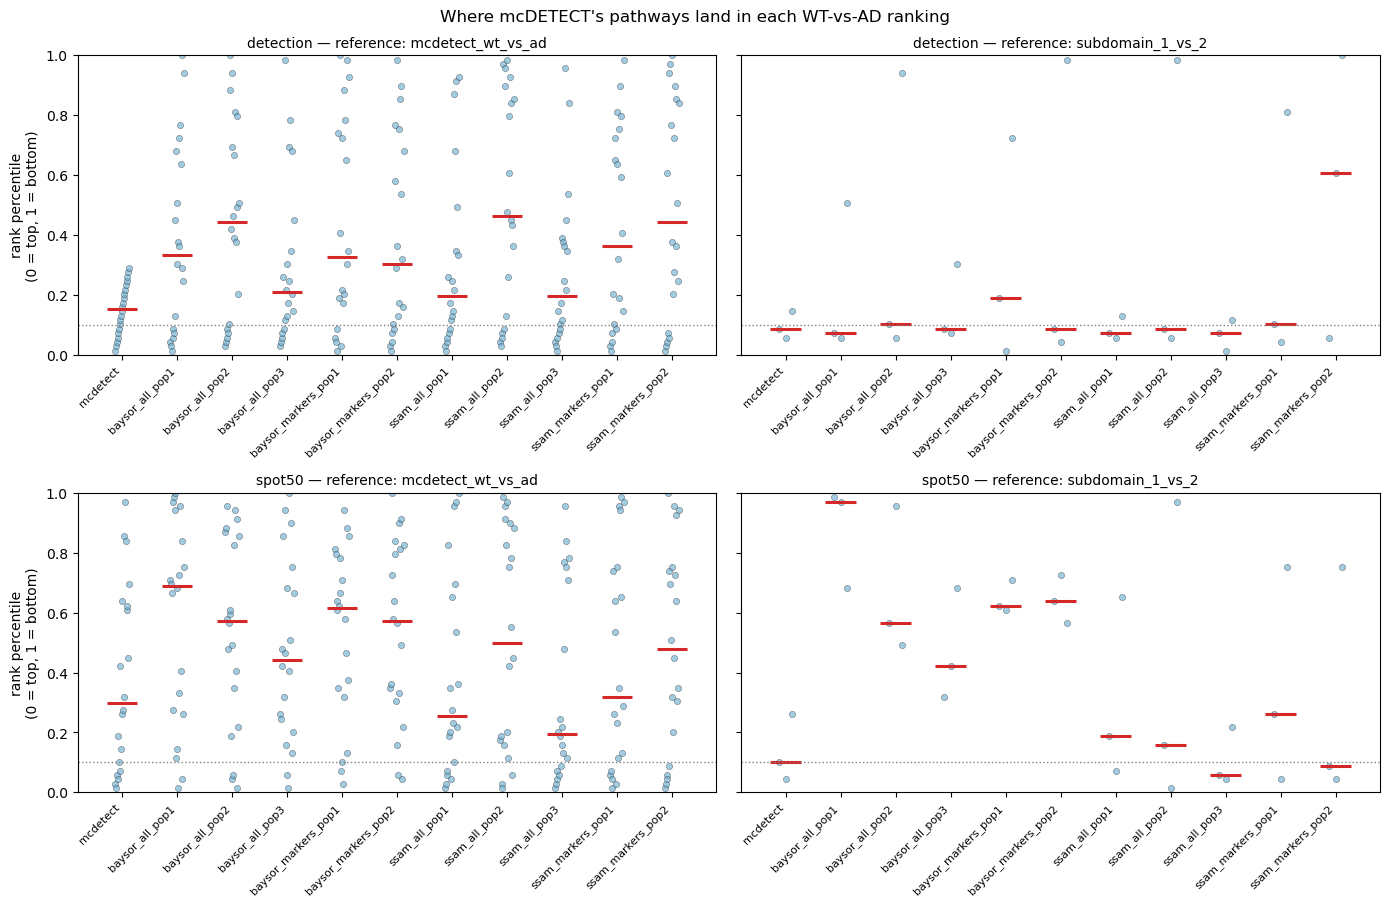

In [15]:
# Rank-position plot: low percentile = mcDETECT's pathways near the top of that ranking
fig, axes = plt.subplots(len(LEVELS), 2, figsize=(14, 4.6 * len(LEVELS)), sharey=True)
axes = np.atleast_2d(axes)

for row, level in enumerate(LEVELS):
    order = [f"mcdetect_{level}"] + [f"{m}_{g}_{p}_{level}"
                                     for m, g in CONFIGS for p in C.populations(g)]
    order = [o for o in order if o in set(pathway_check["ranking"])]

    for col, source in enumerate(references["source"].unique()):
        ax = axes[row, col]
        sub_chk = pathway_check[(pathway_check["source"] == source)]
        for i, ranking in enumerate(order):
            vals = sub_chk.loc[sub_chk["ranking"] == ranking, "percentile"].dropna()
            if len(vals) == 0:
                continue
            jitter = np.linspace(-0.12, 0.12, len(vals))
            ax.scatter(np.full(len(vals), i) + jitter, vals, s=20, alpha=0.65,
                       color="#6fafd2", edgecolor="black", linewidth=0.3)
            ax.hlines(vals.median(), i - 0.28, i + 0.28, color="#d62728", lw=2.2)
        ax.set_xticks(range(len(order)))
        ax.set_xticklabels([o.replace(f"_{level}", "") for o in order],
                           rotation=45, ha="right", fontsize=8)
        ax.set_ylim(0, 1)
        ax.axhline(0.1, ls=":", color="grey", lw=1)
        ax.set_title(f"{level} — reference: {source}", fontsize=10)
    axes[row, 0].set_ylabel("rank percentile\n(0 = top, 1 = bottom)")

fig.suptitle("Where mcDETECT's pathways land in each WT-vs-AD ranking", fontsize=12)
fig.tight_layout()
fig.savefig(C.POSTPROC_DIR / "pathway_reference_check.jpeg", dpi=300)
plt.show()


## 7. Correctness gates

Two checks, both off by default. The first proves the vectorised profiler reproduces
`mcDETECT.model.profile`; the second proves `register_coords` reproduces the coordinate transform
mcDETECT applied to its own granules.


In [16]:
VALIDATE = False        # set True to run the checks (reads the full WT transcript table)

if VALIDATE:
    sample = "WT"
    n_check = 20_000    # a random subset is enough to prove equivalence

    granules = pd.read_parquet(C.mcdetect_granules_path(sample))
    ref_adata = anndata.read_h5ad(C.MCDETECT_OUT / C.dataset_name(sample) / "granule_adata_tsne.h5ad")

    rng = np.random.default_rng(0)
    idx = np.sort(rng.choice(granules.shape[0], min(n_check, granules.shape[0]), replace=False))

    # (a) profiler vs mcDETECT's own counts
    feats_v, X_v, genes_v = SF.profile_spheres(granules.iloc[idx], sample=sample)
    X_ref = ref_adata.layers["counts"][idx][:, [ref_adata.var_names.get_loc(g) for g in genes_v]]
    diff = abs(X_v - X_ref)
    print("profiler: max abs difference vs mcDETECT:", diff.max() if diff.nnz else 0)
    print("profiler: rows identical:",
          int((np.asarray(diff.sum(axis=1)).ravel() == 0).sum()), "/", len(idx))

    # (b) registration vs the stored global_x_new / global_y_new
    reg = SF.register_coords(granules.iloc[idx], sample)
    for col in ["global_x_new", "global_y_new"]:
        expected = granules[col].to_numpy()[idx]
        if sample == "WT" and col == "global_y_new":
            expected = C.COMBINED_CUTOFF - expected      # register_coords folds in the combined flip
        print(f"registration: max |{col} diff| =",
              float(np.nanmax(np.abs(reg[col].to_numpy() - expected))))


## Outputs

Everything lands in `../output/postproc/` (git-ignored):

| file | contents |
|---|---|
| `detection_counts_vs_mcdetect.csv` / `.jpeg` | the scale check (section 1) |
| `<method>_<sample>_tuned_<geneset>_features.parquet` | per-detection features **+ population flags, `brain_area`, registered coordinates** |
| `<method>_<sample>_tuned_<geneset>_profile.h5ad` | per-detection × 290-gene counts |
| `population_summary.csv` | n and median features per (method × geneset × population) |
| `radius_populations.parquet` | radius per detection, both methods — `A1_figures.R` section 1 |
| `in_soma_summary.csv`, `in_soma_histogram.parquet` | in-nucleus ratio, both denominators — section 2 |
| `nc_summary.csv`, `nc_histogram.parquet` | NC ratio, both denominators — section 3 |
| `marker_frac_threshold_scan.csv` | `pop3` size at each candidate `marker_frac` cutoff (tuning aid) |
| `DE_<method>_tuned_<geneset>_<pop>_<level>_AD_vs_WT.csv` | WT-vs-AD DE, `level ∈ {detection, spot50}` |
| `DE_mcdetect_granules_<level>_AD_vs_WT.csv` | matched mcDETECT reference DE |
| `GSEA_*_AD_vs_WT.csv` | pre-ranked GSEA per ranking |
| `pathway_reference_check_all.csv` / `.jpeg` | where mcDETECT's pathways land |

Then run `A1_figures.R`, whose sections 1-3 consume the radius, in-nucleus and NC exports and write
one summary table plus an overlay and per-population panels for each.

**Scope note.** Sections 1-3 above are the finished part: three per-detection quality measures
(radius, in-nucleus ratio, NC ratio), summarized and visualized per population for both methods,
described on their own terms with no mcDETECT comparison. The WT-vs-AD arm is deferred — sections
4-6 (DE, matched mcDETECT reference, pathway check) still run and still write their tables, but are
not currently part of the response, and `A1_figures.R` sections 4-5 are off by default.
